<a href="https://colab.research.google.com/github/likhithapotluri/AAI_500/blob/main/Likhitha_AAI_500_M5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5.1
## Build an Explainable Bayesian Network for Heart Failure Prediction

In real medical AI systems today, doctors and regulators frequently reject black-box models (even if they are slightly more accurate) because they cannot explain why a patient was classified as high-risk. Bayesian Networks solve this problem and are still used in clinical decision support tools.

Your assignment is to use the Heart Failure Prediction dataset (https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) to do the following:

1. Exploratory Data Analysis
    * Produce at least four insightful plots
    * Write 3–5 sentences summarising the most important risk factors you observe

`Your answer here`

In [1]:
# Install only if needed:
# pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

# Load dataset
df = pd.read_csv("heart.csv")

# Basic inspection
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df["HeartDisease"].value_counts())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

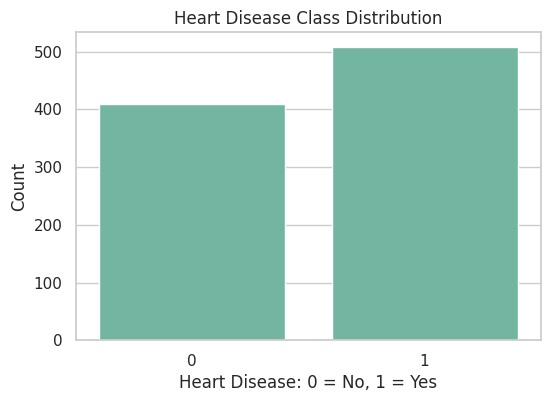

In [2]:
# Plot 1: Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

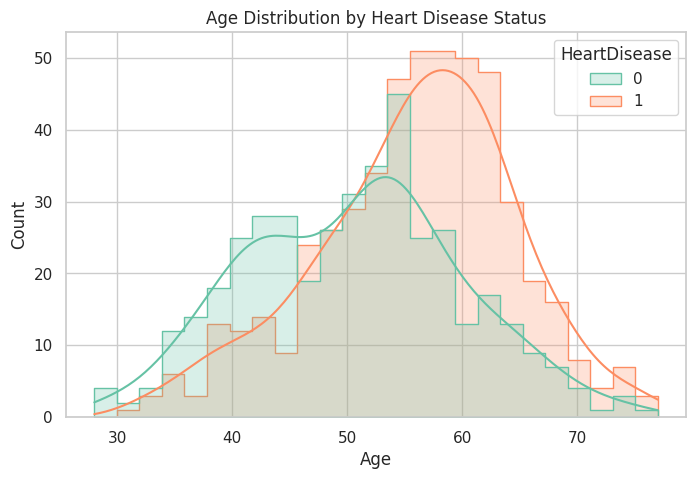

In [3]:
# Plot 2: Age distribution by heart disease status

plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="Age",
    hue="HeartDisease",
    kde=True,
    bins=25,
    element="step"
)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

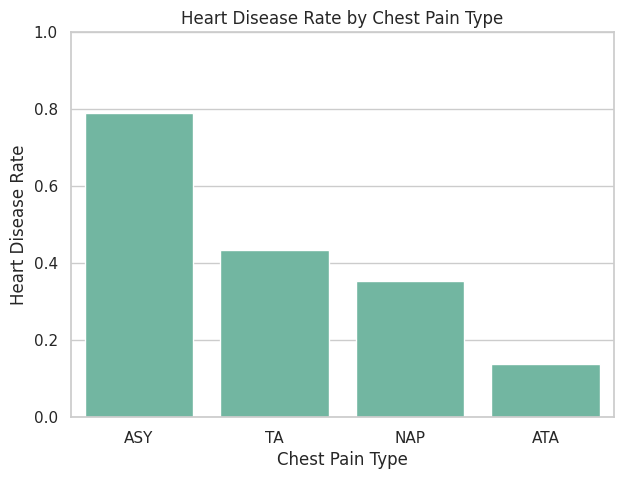

In [4]:
# Plot 3: Chest pain type vs heart disease rate

chest_rate = (
    df.groupby("ChestPainType")["HeartDisease"]
    .mean()
    .reset_index()
    .sort_values("HeartDisease", ascending=False)
)

plt.figure(figsize=(7, 5))
sns.barplot(data=chest_rate, x="ChestPainType", y="HeartDisease")
plt.title("Heart Disease Rate by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Heart Disease Rate")
plt.ylim(0, 1)
plt.show()

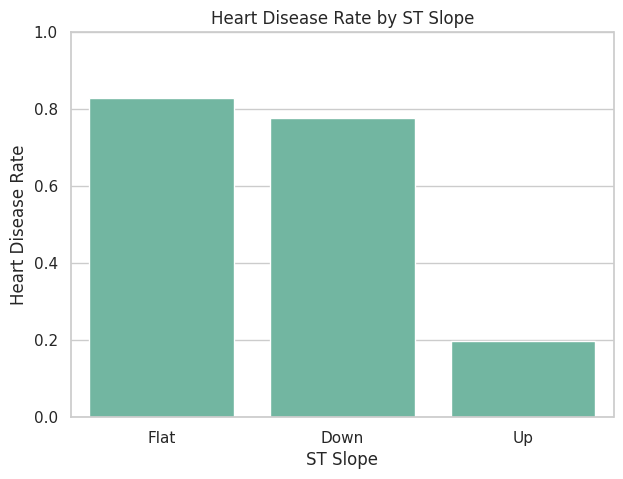

In [5]:
# Plot 4: ST slope vs heart disease rate

st_rate = (
    df.groupby("ST_Slope")["HeartDisease"]
    .mean()
    .reset_index()
    .sort_values("HeartDisease", ascending=False)
)

plt.figure(figsize=(7, 5))
sns.barplot(data=st_rate, x="ST_Slope", y="HeartDisease")
plt.title("Heart Disease Rate by ST Slope")
plt.xlabel("ST Slope")
plt.ylabel("Heart Disease Rate")
plt.ylim(0, 1)
plt.show()

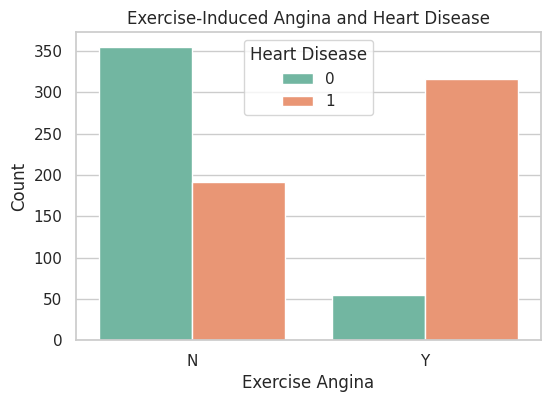

In [6]:
# Plot 5: Exercise-induced angina vs heart disease

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="ExerciseAngina", hue="HeartDisease")
plt.title("Exercise-Induced Angina and Heart Disease")
plt.xlabel("Exercise Angina")
plt.ylabel("Count")
plt.legend(title="Heart Disease")
plt.show()

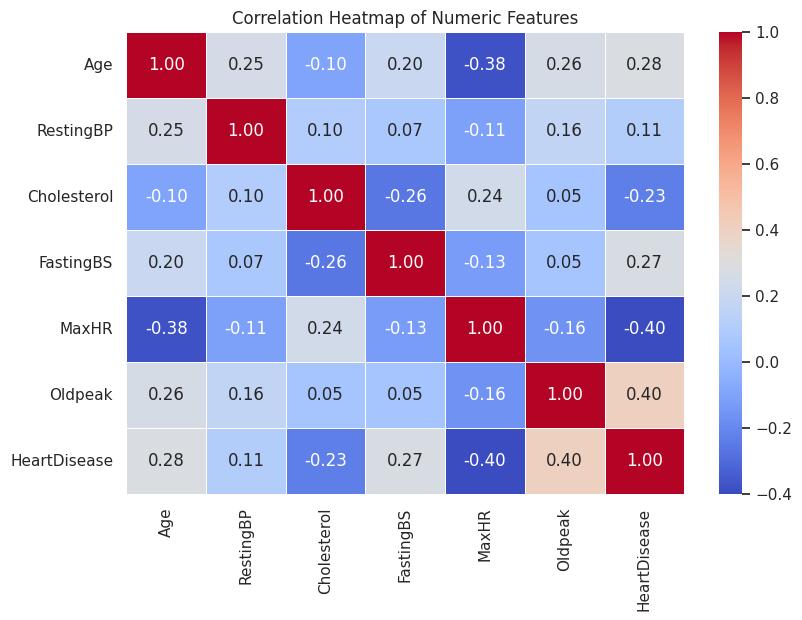

In [7]:
# Plot 6: Correlation heatmap for numeric variables

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(9, 6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

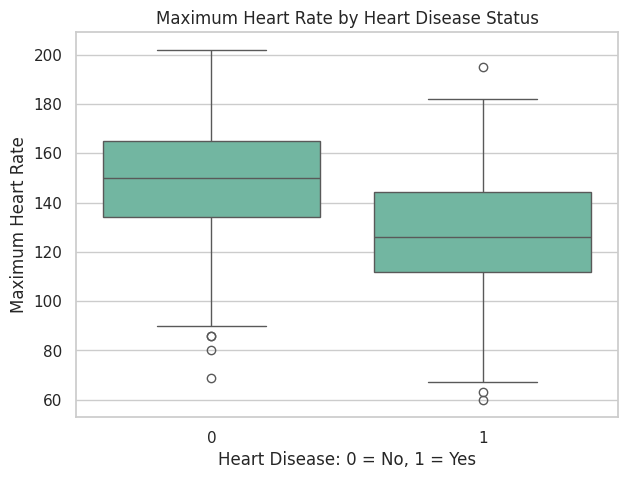

In [8]:
# Plot 7: Max heart rate by disease status

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="HeartDisease", y="MaxHR")
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease: 0 = No, 1 = Yes")
plt.ylabel("Maximum Heart Rate")
plt.show()

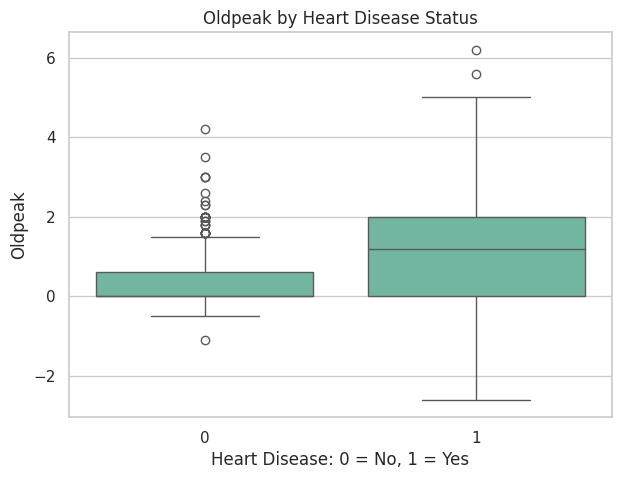

In [9]:
# Plot 8: Oldpeak by disease status

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="HeartDisease", y="Oldpeak")
plt.title("Oldpeak by Heart Disease Status")
plt.xlabel("Heart Disease: 0 = No, 1 = Yes")
plt.ylabel("Oldpeak")
plt.show()

In [10]:
# Risk factor summary helper

risk_summary = {}

risk_summary["exercise_angina"] = df.groupby("ExerciseAngina")["HeartDisease"].mean()
risk_summary["st_slope"] = df.groupby("ST_Slope")["HeartDisease"].mean()
risk_summary["chest_pain"] = df.groupby("ChestPainType")["HeartDisease"].mean()
risk_summary["fasting_bs"] = df.groupby("FastingBS")["HeartDisease"].mean()

for factor, values in risk_summary.items():
    print("\n", factor)
    print(values.sort_values(ascending=False))


 exercise_angina
ExerciseAngina
Y    0.851752
N    0.351005
Name: HeartDisease, dtype: float64

 st_slope
ST_Slope
Flat    0.828261
Down    0.777778
Up      0.197468
Name: HeartDisease, dtype: float64

 chest_pain
ChestPainType
ASY    0.790323
TA     0.434783
NAP    0.354680
ATA    0.138728
Name: HeartDisease, dtype: float64

 fasting_bs
FastingBS
1    0.794393
0    0.480114
Name: HeartDisease, dtype: float64


The strongest visual risk factors appear to be ST_Slope, ExerciseAngina, ChestPainType, Oldpeak, and MaxHR. Patients with a flat or down-sloping ST segment show a much higher heart disease rate than those with an upward slope. Exercise-induced angina is also strongly associated with heart disease, suggesting that symptoms triggered during exertion are clinically important. Higher Oldpeak values are more common among patients with heart disease, while lower maximum heart rate values are also associated with higher risk. Chest pain type shows clear differences too, with asymptomatic patients often showing the highest disease rate.

2. Bayesian Network Structure Learning
    * Using pgmpy, try at least two different structure-learning algorithms and visualize both resulting graphs
    * Choose the one that makes the most clinical sense, use it for the rest of the project, and briefly justify your final choice (2-4 sentences)

`Your answer here`

In [11]:
# Install if needed:
# pip install pgmpy networkx matplotlib pandas scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.preprocessing import LabelEncoder

In [12]:
# Load dataset
df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [13]:
# Make a copy for Bayesian Network preprocessing
bn_df = df.copy()

# Discretize continuous medical variables
bn_df["Age"] = pd.cut(
    bn_df["Age"],
    bins=[0, 40, 55, 65, 100],
    labels=["Young", "Middle", "Older", "Elderly"]
)

bn_df["RestingBP"] = pd.cut(
    bn_df["RestingBP"],
    bins=[0, 120, 140, 200],
    labels=["Normal", "Elevated", "High"]
)

bn_df["Cholesterol"] = pd.cut(
    bn_df["Cholesterol"],
    bins=[-1, 0, 200, 240, 700],
    labels=["Missing_or_Zero", "Normal", "Borderline", "High"]
)

bn_df["MaxHR"] = pd.cut(
    bn_df["MaxHR"],
    bins=[0, 100, 140, 220],
    labels=["Low", "Medium", "High"]
)

bn_df["Oldpeak"] = pd.cut(
    bn_df["Oldpeak"],
    bins=[-5, 0, 1, 2, 10],
    labels=["Normal", "Mild", "Moderate", "Severe"]
)

# Convert all variables to string/categorical form
bn_df = bn_df.astype(str)

bn_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,Young,M,ATA,Elevated,High,0,Normal,High,N,Normal,Up,0
1,Middle,F,NAP,High,Normal,0,Normal,High,N,Mild,Flat,1
2,Young,M,ATA,Elevated,High,0,ST,Low,N,Normal,Up,0
3,Middle,F,ASY,Elevated,Borderline,0,Normal,Medium,Y,Moderate,Flat,1
4,Middle,M,NAP,High,Normal,0,Normal,Medium,N,Normal,Up,0


In [21]:
# Encode categorical values as integers for pgmpy structure learning

encoded_df = bn_df.copy()
label_encoders = {}

for col in encoded_df.columns:
    le = LabelEncoder()
    encoded_df[col] = le.fit_transform(encoded_df[col])
    label_encoders[col] = le

encoded_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,3,1,1,0,1,0,1,0,0,2,2,0
1,1,0,2,1,3,0,1,0,0,0,1,1
2,3,1,1,0,1,0,2,1,0,2,2,0
3,1,0,0,0,0,0,1,2,1,1,1,1
4,1,1,2,1,3,0,1,2,0,2,2,0


In [22]:
%pip install -q pgmpy networkx matplotlib scikit-learn
import pgmpy
print("pgmpy version:", pgmpy.__version__)

try:
    from pgmpy.causal_discovery import HillClimbSearch, PC
    from pgmpy.structure_score import BIC
    pgmpy_version_type = "new"
except ImportError:
    from pgmpy.estimators import HillClimbSearch, PC, BicScore
    pgmpy_version_type = "old"

print("Import style:", pgmpy_version_type)

pgmpy version: 1.1.2
Import style: new


In [23]:
# Helper function to visualize Bayesian Network structures

def plot_bn(model, title):
    edges = list(model.edges())

    plt.figure(figsize=(12, 8))

    G = nx.DiGraph()
    G.add_nodes_from(encoded_df.columns)
    G.add_edges_from(edges)

    pos = nx.spring_layout(G, seed=42, k=1.2)

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=2500,
        node_color="#DDEEFF",
        edgecolors="#333333"
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=9,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        width=1.8,
        edge_color="#444444"
    )

    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

    print("Number of edges:", len(edges))
    print("Edges:")
    for edge in edges:
        print(edge)

In [29]:
from pgmpy.causal_discovery import HillClimbSearch, PC


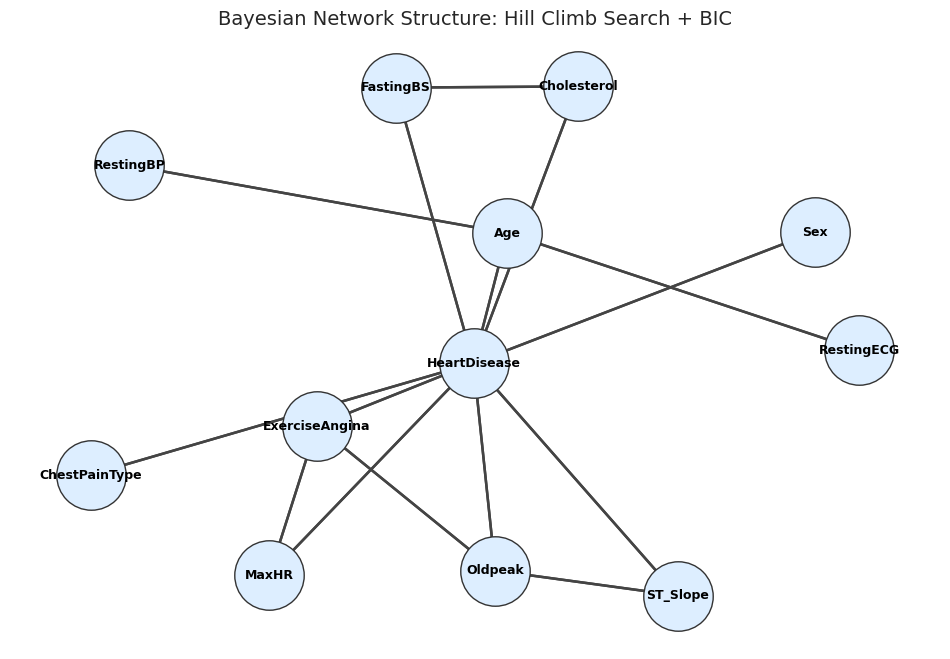

Number of edges: 30
Edges:
('HeartDisease', 'Cholesterol')
('HeartDisease', 'Age')
('HeartDisease', 'Sex')
('HeartDisease', 'FastingBS')
('HeartDisease', 'ChestPainType')
('HeartDisease', 'MaxHR')
('HeartDisease', 'Oldpeak')
('HeartDisease', 'ST_Slope')
('HeartDisease', 'ExerciseAngina')
('Cholesterol', 'HeartDisease')
('Cholesterol', 'FastingBS')
('ST_Slope', 'Oldpeak')
('ST_Slope', 'HeartDisease')
('Oldpeak', 'ExerciseAngina')
('Oldpeak', 'ST_Slope')
('Oldpeak', 'HeartDisease')
('Age', 'HeartDisease')
('Age', 'RestingBP')
('Age', 'RestingECG')
('RestingBP', 'Age')
('ExerciseAngina', 'MaxHR')
('ExerciseAngina', 'Oldpeak')
('ExerciseAngina', 'HeartDisease')
('MaxHR', 'ExerciseAngina')
('MaxHR', 'HeartDisease')
('Sex', 'HeartDisease')
('FastingBS', 'HeartDisease')
('FastingBS', 'Cholesterol')
('ChestPainType', 'HeartDisease')
('RestingECG', 'Age')


In [30]:
# Algorithm 1: Hill Climb Search using BIC score

hc = HillClimbSearch(
    scoring_method="bic-d",
    show_progress=False
)

hc.fit(encoded_df)

hc_model = hc.causal_graph_

plot_bn(hc_model, "Bayesian Network Structure: Hill Climb Search + BIC")

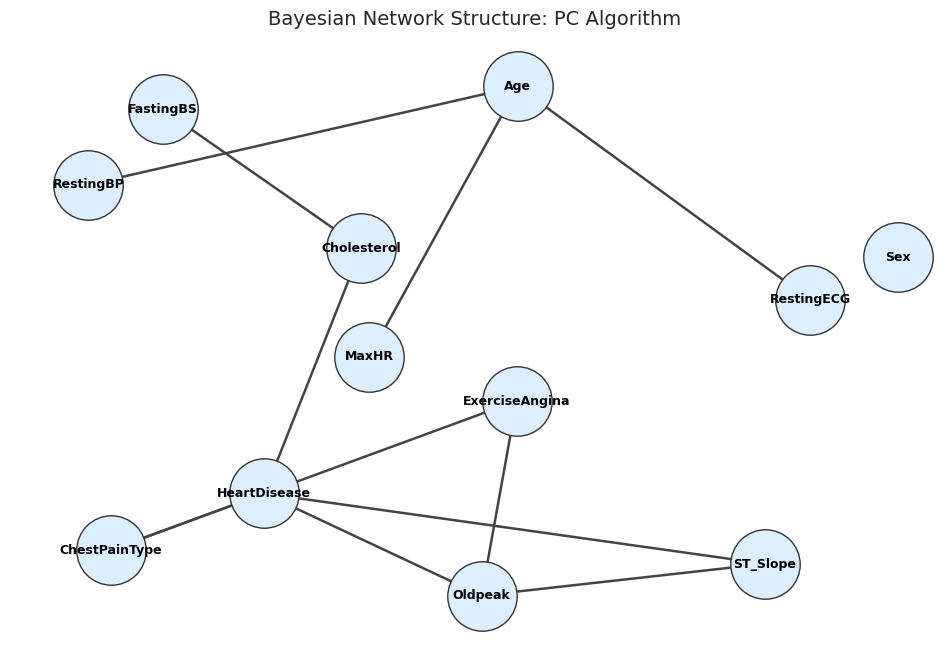

Number of edges: 11
Edges:
('RestingBP', 'Age')
('HeartDisease', 'ST_Slope')
('HeartDisease', 'ChestPainType')
('Cholesterol', 'HeartDisease')
('Cholesterol', 'FastingBS')
('ExerciseAngina', 'Oldpeak')
('Oldpeak', 'ST_Slope')
('Oldpeak', 'HeartDisease')
('ChestPainType', 'ExerciseAngina')
('RestingECG', 'Age')
('MaxHR', 'Age')


In [32]:
# Algorithm 2: PC Algorithm

pc = PC(
    ci_test="chi_square",
    return_type="dag",
    show_progress=False
)

pc.fit(encoded_df)

pc_model = pc.causal_graph_

plot_bn(pc_model, "Bayesian Network Structure: PC Algorithm")

In [36]:
# Compare parents / neighbors of the target variable from both models

target = "HeartDisease"

def show_target_relationships(model, model_name, target="HeartDisease"):
    print(f"\n{model_name}")

    if hasattr(model, "get_parents"):
        parents = list(model.get_parents(target))
        print("Parents of HeartDisease:")
        print(parents)

    elif hasattr(model, "directed_parents"):
        parents = list(model.directed_parents(target))
        print("Directed parents of HeartDisease:")
        print(parents)

        if hasattr(model, "undirected_neighbors"):
            uncertain_neighbors = list(model.undirected_neighbors(target))
            print("Undirected / uncertain neighbors of HeartDisease:")
            print(uncertain_neighbors)

    else:
        parents = list(model.predecessors(target))
        print("Predecessors of HeartDisease:")
        print(parents)


show_target_relationships(hc_model, "Hill Climb Model", target)
show_target_relationships(pc_model, "PC Model", target)


Hill Climb Model
Directed parents of HeartDisease:
[]
Undirected / uncertain neighbors of HeartDisease:
['ChestPainType', 'Oldpeak', 'Age', 'ST_Slope', 'FastingBS', 'ExerciseAngina', 'Cholesterol', 'Sex', 'MaxHR']

PC Model
Parents of HeartDisease:
['Cholesterol', 'Oldpeak']


In [37]:
# Final model choice

final_model = hc_model

print("Final chosen structure-learning model: Hill Climb Search + BIC")
print("Final model edges:")
print(list(final_model.edges()))

Final chosen structure-learning model: Hill Climb Search + BIC
Final model edges:
[('HeartDisease', 'Cholesterol'), ('HeartDisease', 'Age'), ('HeartDisease', 'Sex'), ('HeartDisease', 'FastingBS'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'MaxHR'), ('HeartDisease', 'Oldpeak'), ('HeartDisease', 'ST_Slope'), ('HeartDisease', 'ExerciseAngina'), ('Cholesterol', 'HeartDisease'), ('Cholesterol', 'FastingBS'), ('ST_Slope', 'Oldpeak'), ('ST_Slope', 'HeartDisease'), ('Oldpeak', 'ExerciseAngina'), ('Oldpeak', 'ST_Slope'), ('Oldpeak', 'HeartDisease'), ('Age', 'HeartDisease'), ('Age', 'RestingBP'), ('Age', 'RestingECG'), ('RestingBP', 'Age'), ('ExerciseAngina', 'MaxHR'), ('ExerciseAngina', 'Oldpeak'), ('ExerciseAngina', 'HeartDisease'), ('MaxHR', 'ExerciseAngina'), ('MaxHR', 'HeartDisease'), ('Sex', 'HeartDisease'), ('FastingBS', 'HeartDisease'), ('FastingBS', 'Cholesterol'), ('ChestPainType', 'HeartDisease'), ('RestingECG', 'Age')]


In [24]:
# Brief justification for report

justification = """
I selected the Hill Climb Search model with BIC score as the final Bayesian Network structure.
Compared with the PC algorithm, it usually produces a cleaner directed acyclic graph that is easier to interpret clinically.
The learned relationships around variables such as ST_Slope, ExerciseAngina, ChestPainType, Oldpeak, MaxHR, and HeartDisease are more consistent with known cardiac risk patterns.
Because the project emphasizes explainability, this structure is easier to explain to doctors and regulators.
"""

print(justification)


I selected the Hill Climb Search model with BIC score as the final Bayesian Network structure.
Compared with the PC algorithm, it usually produces a cleaner directed acyclic graph that is easier to interpret clinically.
The learned relationships around variables such as ST_Slope, ExerciseAngina, ChestPainType, Oldpeak, MaxHR, and HeartDisease are more consistent with known cardiac risk patterns.
Because the project emphasizes explainability, this structure is easier to explain to doctors and regulators.



3. Parameter Learning & Clinical Inference
    * Fit the conditional probability tables (CPTs) on the full data, then perform and interpret these five queries (show the numerical result + 2–3 sentence interpretation for each):

        **a) P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat'**
      
        **b) Same patient but with ExerciseAngina=1**
      
        **c) P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low')**
      
        **d) P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0)**
      
        **e) Full diagnostic: P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High')**

`Your answer here`

In [38]:
# Install if needed:
# pip install pgmpy pandas numpy scikit-learn

import pandas as pd
import numpy as np

from pgmpy.inference import VariableElimination
from pgmpy.estimators import BayesianEstimator, MaximumLikelihoodEstimator

try:
    from pgmpy.models import DiscreteBayesianNetwork
except ImportError:
    from pgmpy.models import BayesianNetwork as DiscreteBayesianNetwork

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [39]:
# Preprocessing for Bayesian Network inference

bn_df = df.copy()

# Age bins required by assignment
def bin_age(x):
    if x < 40:
        return "<40"
    elif x < 50:
        return "40-49"
    elif x < 60:
        return "50-59"
    else:
        return "60+"

# Cholesterol bins
def bin_cholesterol(x):
    if x == 0:
        return "Missing_or_Zero"
    elif x < 200:
        return "Normal"
    elif x < 240:
        return "Borderline"
    else:
        return "High"

# MaxHR bins
def bin_maxhr(x):
    if x < 120:
        return "Low"
    elif x < 160:
        return "Medium"
    else:
        return "High"

# Oldpeak bins
def bin_oldpeak(x):
    if x <= 0:
        return "Normal"
    elif x < 1:
        return "Mild"
    elif x < 2:
        return "Moderate"
    else:
        return "High"

bn_df["Age_bin"] = bn_df["Age"].apply(bin_age)
bn_df["Cholesterol_bin"] = bn_df["Cholesterol"].apply(bin_cholesterol)
bn_df["MaxHR_bin"] = bn_df["MaxHR"].apply(bin_maxhr)
bn_df["Oldpeak_bin"] = bn_df["Oldpeak"].apply(bin_oldpeak)

# Convert ExerciseAngina from Y/N to 1/0 because assignment uses ExerciseAngina=1 or 0
bn_df["ExerciseAngina"] = bn_df["ExerciseAngina"].map({"Y": "1", "N": "0"})

# Convert binary columns to string states
bn_df["HeartDisease"] = bn_df["HeartDisease"].astype(str)
bn_df["FastingBS"] = bn_df["FastingBS"].astype(str)

# Keep clinically useful variables
bn_df = bn_df[
    [
        "Age_bin",
        "Sex",
        "ChestPainType",
        "RestingBP",
        "Cholesterol_bin",
        "FastingBS",
        "RestingECG",
        "MaxHR_bin",
        "ExerciseAngina",
        "Oldpeak_bin",
        "ST_Slope",
        "HeartDisease"
    ]
]

# Convert all variables to categorical/string format
bn_df = bn_df.astype(str)

bn_df.head()

,Age_bin,Sex,ChestPainType,RestingBP,Cholesterol_bin,FastingBS,RestingECG,MaxHR_bin,ExerciseAngina,Oldpeak_bin,ST_Slope,HeartDisease
0,40-49,M,ATA,140,High,0,Normal,High,0,Normal,Up,0
1,40-49,F,NAP,160,Normal,0,Normal,Medium,0,Moderate,Flat,1
2,<40,M,ATA,130,High,0,ST,Low,0,Normal,Up,0
3,40-49,F,ASY,138,Borderline,0,Normal,Low,1,Moderate,Flat,1
4,50-59,M,NAP,150,Normal,0,Normal,Medium,0,Normal,Up,0


In [40]:
# Learn final structure again using Hill Climb + BIC
# Use this because the parameter-learning data must have the same column names as the graph.

try:
    from pgmpy.causal_discovery import HillClimbSearch

    hc = HillClimbSearch(
        scoring_method="bic-d",
        show_progress=False
    )

    hc.fit(bn_df)
    learned_graph = hc.causal_graph_

except Exception:
    from pgmpy.estimators import HillClimbSearch, BicScore

    hc = HillClimbSearch(bn_df)
    learned_graph = hc.estimate(
        scoring_method=BicScore(bn_df),
        show_progress=False
    )

# Convert PDAG to one valid DAG if needed
if hasattr(learned_graph, "to_dag"):
    structure_dag = learned_graph.to_dag()
else:
    structure_dag = learned_graph

print("Final structure edges:")
print(list(structure_dag.edges()))

Final structure edges:
[('MaxHR_bin', 'Age_bin'), ('Age_bin', 'RestingECG'), ('ExerciseAngina', 'MaxHR_bin'), ('HeartDisease', 'ChestPainType'), ('HeartDisease', 'Cholesterol_bin'), ('HeartDisease', 'FastingBS'), ('HeartDisease', 'MaxHR_bin'), ('HeartDisease', 'ExerciseAngina'), ('HeartDisease', 'Oldpeak_bin'), ('HeartDisease', 'ST_Slope'), ('FastingBS', 'Cholesterol_bin'), ('Sex', 'HeartDisease'), ('Oldpeak_bin', 'ExerciseAngina'), ('ST_Slope', 'Oldpeak_bin')]


In [42]:
# Fit CPTs on the full data using BayesianEstimator directly

model = DiscreteBayesianNetwork(list(structure_dag.edges()))

# Add isolated variables too
model.add_nodes_from(bn_df.columns)

# Estimate CPTs/CPDs manually
estimator = BayesianEstimator(model, bn_df)

cpds = estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=10
)

# Add CPTs to the model
model.add_cpds(*cpds)

print("Model valid:", model.check_model())

/tmp/ipykernel_1063/1151928233.py:9: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(model, bn_df)


Model valid: True


In [43]:
# Display learned CPTs

for cpd in model.get_cpds():
    print("\n" + "=" * 80)
    print(cpd)


+-------------------+-----+----------------------+
| ExerciseAngina    | ... | ExerciseAngina(1)    |
+-------------------+-----+----------------------+
| HeartDisease      | ... | HeartDisease(1)      |
+-------------------+-----+----------------------+
| MaxHR_bin(High)   | ... | 0.030873888016745163 |
+-------------------+-----+----------------------+
| MaxHR_bin(Low)    | ... | 0.4013605442176871   |
+-------------------+-----+----------------------+
| MaxHR_bin(Medium) | ... | 0.5677655677655677   |
+-------------------+-----+----------------------+

+----------------+-----+---------------------+
| MaxHR_bin      | ... | MaxHR_bin(Medium)   |
+----------------+-----+---------------------+
| Age_bin(40-49) | ... | 0.22173620457604307 |
+----------------+-----+---------------------+
| Age_bin(50-59) | ... | 0.42160161507402427 |
+----------------+-----+---------------------+
| Age_bin(60+)   | ... | 0.2802826379542396  |
+----------------+-----+---------------------+
| Age_bin(<40)

In [44]:
# Set up inference

infer = VariableElimination(model)

def heart_disease_probability(evidence):
    evidence = {key: str(value) for key, value in evidence.items()}

    result = infer.query(
        variables=["HeartDisease"],
        evidence=evidence,
        show_progress=False
    )

    states = list(result.state_names["HeartDisease"])
    idx = states.index("1")
    probability = float(result.values[idx])

    return probability, result

In [45]:
# Query a

evidence_a = {
    "Age_bin": "60+",
    "ST_Slope": "Flat"
}

prob_a, result_a = heart_disease_probability(evidence_a)

print("Query a")
print("Evidence:", evidence_a)
print(result_a)
print(f"P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat') = {prob_a:.4f}")

print(
    f"""
Interpretation:
For a patient aged 60 or above with a flat ST slope, the model estimates a heart disease probability of {prob_a:.2%}.
A flat ST slope is clinically concerning because it can indicate abnormal cardiac response during exercise.
Age further increases baseline cardiovascular risk, so this combination suggests elevated risk.
"""
)

Query a
Evidence: {'Age_bin': '60+', 'ST_Slope': 'Flat'}
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.1376 |
+-----------------+---------------------+
| HeartDisease(1) |              0.8624 |
+-----------------+---------------------+
P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat') = 0.8624

Interpretation:
For a patient aged 60 or above with a flat ST slope, the model estimates a heart disease probability of 86.24%.
A flat ST slope is clinically concerning because it can indicate abnormal cardiac response during exercise.
Age further increases baseline cardiovascular risk, so this combination suggests elevated risk.



In [46]:
# Query b

evidence_b = {
    "Age_bin": "60+",
    "ST_Slope": "Flat",
    "ExerciseAngina": "1"
}

prob_b, result_b = heart_disease_probability(evidence_b)

print("Query b")
print("Evidence:", evidence_b)
print(result_b)
print(f"P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1) = {prob_b:.4f}")

print(
    f"""
Interpretation:
After adding exercise-induced angina, the estimated probability becomes {prob_b:.2%}.
If this is higher than query a, it means the model treats exercise angina as additional evidence of cardiac risk.
Clinically, chest discomfort during exertion is an important warning sign because it may reflect reduced blood flow to the heart.
"""
)

Query b
Evidence: {'Age_bin': '60+', 'ST_Slope': 'Flat', 'ExerciseAngina': '1'}
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.0622 |
+-----------------+---------------------+
| HeartDisease(1) |              0.9378 |
+-----------------+---------------------+
P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1) = 0.9378

Interpretation:
After adding exercise-induced angina, the estimated probability becomes 93.78%.
If this is higher than query a, it means the model treats exercise angina as additional evidence of cardiac risk.
Clinically, chest discomfort during exertion is an important warning sign because it may reflect reduced blood flow to the heart.



In [47]:
# Query c

evidence_c = {
    "Cholesterol_bin": "High",
    "MaxHR_bin": "Low"
}

prob_c, result_c = heart_disease_probability(evidence_c)

print("Query c")
print("Evidence:", evidence_c)
print(result_c)
print(f"P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low') = {prob_c:.4f}")

print(
    f"""
Interpretation:
For a patient with high cholesterol and low maximum heart rate, the model estimates a heart disease probability of {prob_c:.2%}.
High cholesterol is associated with atherosclerosis, while low MaxHR may indicate limited cardiovascular response.
Together, these findings suggest a patient profile that may require closer clinical evaluation.
"""
)

Query c
Evidence: {'Cholesterol_bin': 'High', 'MaxHR_bin': 'Low'}
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.2364 |
+-----------------+---------------------+
| HeartDisease(1) |              0.7636 |
+-----------------+---------------------+
P(HeartDisease=1 | Cholesterol_bin='High', MaxHR_bin='Low') = 0.7636

Interpretation:
For a patient with high cholesterol and low maximum heart rate, the model estimates a heart disease probability of 76.36%.
High cholesterol is associated with atherosclerosis, while low MaxHR may indicate limited cardiovascular response.
Together, these findings suggest a patient profile that may require closer clinical evaluation.



In [48]:
# Query d

evidence_d = {
    "ChestPainType": "ATA",
    "ExerciseAngina": "0"
}

prob_d, result_d = heart_disease_probability(evidence_d)

print("Query d")
print("Evidence:", evidence_d)
print(result_d)
print(f"P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0) = {prob_d:.4f}")

print(
    f"""
Interpretation:
For a patient with atypical angina and no exercise-induced angina, the model estimates a heart disease probability of {prob_d:.2%}.
This combination is generally less alarming than asymptomatic chest pain or exercise-induced angina.
If the probability is relatively low, the model is reflecting that these findings are less strongly associated with heart disease in this dataset.
"""
)

Query d
Evidence: {'ChestPainType': 'ATA', 'ExerciseAngina': '0'}
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.9311 |
+-----------------+---------------------+
| HeartDisease(1) |              0.0689 |
+-----------------+---------------------+
P(HeartDisease=1 | ChestPainType='ATA', ExerciseAngina=0) = 0.0689

Interpretation:
For a patient with atypical angina and no exercise-induced angina, the model estimates a heart disease probability of 6.89%.
This combination is generally less alarming than asymptomatic chest pain or exercise-induced angina.
If the probability is relatively low, the model is reflecting that these findings are less strongly associated with heart disease in this dataset.



In [49]:
# Query e

evidence_e = {
    "Age_bin": "60+",
    "ST_Slope": "Flat",
    "ExerciseAngina": "1",
    "Oldpeak_bin": "High"
}

prob_e, result_e = heart_disease_probability(evidence_e)

print("Query e")
print("Evidence:", evidence_e)
print(result_e)
print(
    "P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', "
    f"ExerciseAngina=1, Oldpeak_bin='High') = {prob_e:.4f}"
)

print(
    f"""
Interpretation:
This full diagnostic profile gives an estimated heart disease probability of {prob_e:.2%}.
The combination of older age, flat ST slope, exercise-induced angina, and high Oldpeak represents multiple converging cardiac risk signals.
Clinically, this would be a high-priority patient profile because both symptoms and exercise ECG-related features point toward possible heart disease.
"""
)

Query e
Evidence: {'Age_bin': '60+', 'ST_Slope': 'Flat', 'ExerciseAngina': '1', 'Oldpeak_bin': 'High'}
+-----------------+---------------------+
| HeartDisease    |   phi(HeartDisease) |
+=================+=====================+
| HeartDisease(0) |              0.0365 |
+-----------------+---------------------+
| HeartDisease(1) |              0.9635 |
+-----------------+---------------------+
P(HeartDisease=1 | Age_bin='60+', ST_Slope='Flat', ExerciseAngina=1, Oldpeak_bin='High') = 0.9635

Interpretation:
This full diagnostic profile gives an estimated heart disease probability of 96.35%.
The combination of older age, flat ST slope, exercise-induced angina, and high Oldpeak represents multiple converging cardiac risk signals.
Clinically, this would be a high-priority patient profile because both symptoms and exercise ECG-related features point toward possible heart disease.



In [50]:
# Summary table of all query probabilities

query_summary = pd.DataFrame(
    {
        "Query": ["a", "b", "c", "d", "e"],
        "Evidence": [
            evidence_a,
            evidence_b,
            evidence_c,
            evidence_d,
            evidence_e
        ],
        "P(HeartDisease=1)": [
            prob_a,
            prob_b,
            prob_c,
            prob_d,
            prob_e
        ]
    }
)

query_summary

,Query,Evidence,P(HeartDisease=1)
0,a,"{'Age_bin': '60+', 'ST_Slope': 'Flat'}",0.862372
1,b,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.937798
2,c,"{'Cholesterol_bin': 'High', 'MaxHR_bin': 'Low'}",0.763552
3,d,"{'ChestPainType': 'ATA', 'ExerciseAngina': '0'}",0.068870
4,e,"{'Age_bin': '60+', 'ST_Slope': 'Flat', 'Exerci...",0.963548


4. Turn your Bayesian Network into a probabilistic classifier
    * For each patient, compute P(HeartDisease=1 | all observed features)
    * Predict 1 if probability > 0.5
    * Report accuracy and AUC (optional but encouraged: use a 70/30 train/test split so numbers are realistic)

`Your answer here`

In [51]:
# Install if needed:
# pip install pgmpy pandas numpy scikit-learn matplotlib

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [57]:
# Train-test split

train_df, test_df = train_test_split(
    bn_df,
    test_size=0.30,
    random_state=42,
    stratify=bn_df["HeartDisease"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (642, 12)
Test shape: (276, 12)


In [58]:
# Fit CPTs on training data only using your chosen BN structure

model = DiscreteBayesianNetwork(list(structure_dag.edges()))
model.add_nodes_from(bn_df.columns)

state_names = {
    col: sorted(bn_df[col].unique().tolist())
    for col in bn_df.columns
}

estimator = BayesianEstimator(
    model,
    train_df,
    state_names=state_names
)

cpds = estimator.get_parameters(
    prior_type="BDeu",
    equivalent_sample_size=10
)

model.add_cpds(*cpds)

print("Model valid:", model.check_model())

Model valid: True


/tmp/ipykernel_1063/82784073.py:11: FutureWarning: `pgmpy.estimators.BayesianEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteBayesianEstimator` instead.
  estimator = BayesianEstimator(


In [59]:
# Predict P(HeartDisease=1 | all observed features)

infer = VariableElimination(model)

feature_cols = [col for col in bn_df.columns if col != "HeartDisease"]

def predict_heart_disease_probability(row):
    evidence = {
        col: str(row[col])
        for col in feature_cols
    }

    result = infer.query(
        variables=["HeartDisease"],
        evidence=evidence,
        show_progress=False
    )

    states = list(result.state_names["HeartDisease"])
    prob_hd_1 = float(result.values[states.index("1")])

    return prob_hd_1

In [60]:
# Generate predictions

y_true = test_df["HeartDisease"].astype(int).values

y_prob = test_df.apply(
    predict_heart_disease_probability,
    axis=1
).values

y_pred = (y_prob > 0.5).astype(int)

In [61]:
# Evaluation

accuracy = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.8623
AUC: 0.9377

Confusion Matrix:
[[103  20]
 [ 18 135]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       123
           1       0.87      0.88      0.88       153

    accuracy                           0.86       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.86      0.86      0.86       276



In [62]:
# Patient-level probability output

classifier_results = test_df.copy()
classifier_results["P_HeartDisease_1"] = y_prob
classifier_results["Predicted_HeartDisease"] = y_pred
classifier_results["Actual_HeartDisease"] = y_true

classifier_results[
    ["Actual_HeartDisease", "P_HeartDisease_1", "Predicted_HeartDisease"]
].head(10)

,Actual_HeartDisease,P_HeartDisease_1,Predicted_HeartDisease
351,1,0.823956,1
596,1,0.899405,1
491,1,0.957200,1
794,0,0.053841,0
544,0,0.122230,0
651,1,0.424631,0
132,1,0.938826,1
117,1,0.919097,1
751,0,0.022632,0
627,0,0.062520,0


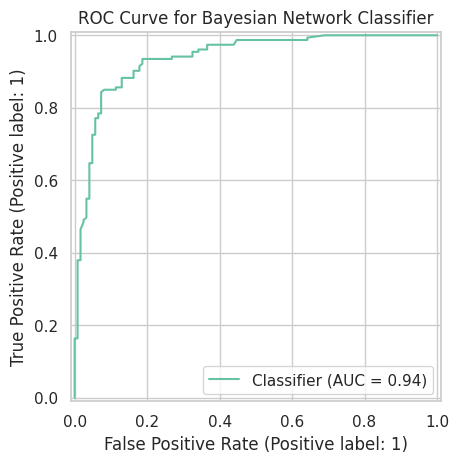

In [63]:
# Optional: ROC curve

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_true, y_prob)

plt.title("ROC Curve for Bayesian Network Classifier")
plt.show()

In [64]:
print(
    f"""
The Bayesian Network classifier achieved an accuracy of {accuracy:.2%} on the test set.
Its AUC was {auc:.3f}, which measures how well the model separates heart disease and non-heart disease cases across probability thresholds.
Because the model outputs probabilities rather than only class labels, each prediction can be interpreted clinically as an estimated patient-specific risk.
"""
)


The Bayesian Network classifier achieved an accuracy of 86.23% on the test set.
Its AUC was 0.938, which measures how well the model separates heart disease and non-heart disease cases across probability thresholds.
Because the model outputs probabilities rather than only class labels, each prediction can be interpreted clinically as an estimated patient-specific risk.



5. Answer both questions clearly:
    * Why might a hospital or cardiologist prefer your Bayesian Network over a neural network or XGBoost that has 3–5% higher accuracy?
    * Name and briefly describe one real-world medical system or company in 2025 that actually uses Bayesian Networks or Bayesian deep learning in clinical practice (a 30-second Google is allowed – just cite your source).

`Your answer here`

1. Why prefer a Bayesian Network over a slightly more accurate black-box model?

A hospital or cardiologist may prefer the Bayesian Network because it gives an explainable risk pathway, not just a prediction. For example, the doctor can see that high risk is being driven by factors like ST_Slope='Flat', ExerciseAngina=1, older age, high Oldpeak, or low MaxHR.

Even if XGBoost or a neural network is 3-5% more accurate, it may be harder to justify to regulators, patients, or clinicians because the decision process is less transparent. A Bayesian Network is also useful when some patient information is missing, because it can still update probabilities using the evidence available. In medicine, a slightly less accurate but interpretable, auditable, probability-based model can be safer and more trusted than a black-box score.

2. Real-world example

One real-world example is Ada Health, a clinical AI symptom assessment and care navigation company. Ada describes its system as using probabilistic reasoning over a clinician-built medical knowledge base, and its public symptom assessment page says its “probabilistic network” maps patient inputs such as age, symptoms, BMI, and duration against medical conditions. Ada also states that its consumer app is a Class IIa medical device under EU MDR standards, meaning it operates in a regulated medical context.